In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt

In [25]:
transform = transforms.Compose([
    transforms.ToTensor(), # 0 --> 255 ==> (0,1)
    transforms.Normalize((0.5),(0.5)),# (0,1) ==> [-1,1]
])
training_dataset = datasets.MNIST(
    root = "data",
    download = True,
    train = True,
    transform = transform
)
test_dataset = datasets.MNIST(
    root = "data",
    download = True,
    train = False,
    transform = transform
)

In [26]:
len(training_dataset)

60000

In [27]:
len(test_dataset)

10000

In [28]:
train_loader = DataLoader(training_dataset,batch_size = 64,shuffle = True)
test_loader = DataLoader(test_dataset,batch_size = 64,shuffle = True)

In [29]:
data_iter = iter(train_loader)
imgs, labels = next(data_iter)

In [30]:
imgs[0].squeeze().shape

torch.Size([28, 28])

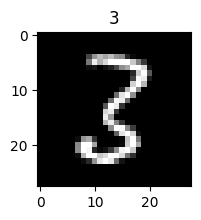

In [31]:
plt.figure(figsize = (2,2))
plt.title(labels[0].item())
plt.imshow(imgs[0].squeeze(),cmap ="gray")
plt.show()


In [34]:
class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network =  nn.Sequential(
            nn.Flatten(),
            nn.Linear(784,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
    def forward(self,x):
        return self.network(x)
        

In [35]:
model = DigitClassifier()
optimizer = optim.Adam(model.parameters(),lr =  0.001)
criterion = nn.CrossEntropyLoss()

In [40]:
epochs = 5
for epoch in range(epochs):
    running_loss = 0.0
    for images,labels in train_loader:
        
        # Forward Pass 
        outputs = model(images)
        loss =  criterion(outputs,labels)

        running_loss += loss.item()
        # Backward Pass
        optimizer.zero_grad()
        loss.backward()
        
        # weights updates
        optimizer.step() # w_new = w_old - n * d(loss)/dw
    print(f" Epoch [{epoch+1}/{epochs}], Loss : {running_loss/len(train_loader):.4f}")

 Epoch [1/5], Loss : 0.3955
 Epoch [2/5], Loss : 0.1936
 Epoch [3/5], Loss : 0.1434
 Epoch [4/5], Loss : 0.1153
 Epoch [5/5], Loss : 0.0970


In [66]:
model.eval()
total = 0
correct = 0
all_predicted = []
all_labels = []
with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = model(imgs) 
        _,predicted = torch.max(outputs.data,1)
        # print(" Predicted Digits :")
        # print(predicted)
        # print(" Actual Digits :")
        # print(labels)
        all_labels.extend(labels.numpy())
        all_predicted.extend(predicted.numpy())
        # print((predicted == labels).sum().item())

        correct +=  (predicted == labels).sum().item()
        total += labels.size(0)
    print(f' Accuracy on the test set : {100 * correct / total:.2f}%')

 Accuracy on the test set : 96.45%


In [63]:
 total 

10000

In [64]:
correct

9645

In [68]:
from sklearn.metrics import classification_report
report = classification_report(all_labels,all_predicted)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       980
           1       0.98      0.98      0.98      1135
           2       0.98      0.94      0.96      1032
           3       0.95      0.97      0.96      1010
           4       0.98      0.96      0.97       982
           5       0.97      0.95      0.96       892
           6       0.97      0.98      0.97       958
           7       0.96      0.96      0.96      1028
           8       0.93      0.98      0.95       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



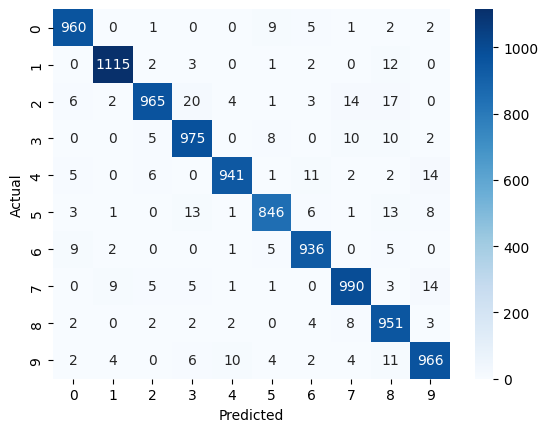

In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_predicted)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()